In [1]:
import sys
from pathlib import Path

# Ensure project root is importable when notebook runs from notebooks/
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("PROJECT_ROOT:", PROJECT_ROOT)


PROJECT_ROOT: d:\Projet\scanned_images_classifier


# OCR Fine-tuning CPU (batch_1 -> batch_2)

Ce notebook entraine un modele OCR image->texte sur `batch_1` avec les annotations CSV (`batch1_1` + `batch1_3`) et evalue sur `batch1_2`, puis teste l'inference sur `batch_2`.


In [2]:
from pathlib import Path
import json

from src.ocr_image_text.config import TrainConfig, InferConfig
from src.ocr_image_text.data import resolve_default_data_root, load_multi_ocr_sources, load_images_from_subdirs
from src.ocr_image_text.train import run_training
from src.ocr_image_text.inference import load_predictor
from src.ocr_image_text.evaluation import evaluate_records


In [3]:
data_root = resolve_default_data_root()

# Force artifacts in notebooks/artifacts to avoid loading stale smoke models from ./artifacts
repo_root = Path.cwd()
if not (repo_root / "src").exists() and (repo_root.parent / "src").exists():
    repo_root = repo_root.parent
output_dir = (repo_root / "notebooks" / "artifacts" / "doc_understanding_ocr_cpu").resolve()
output_dir.mkdir(parents=True, exist_ok=True)

legacy_output_dir = (repo_root / "artifacts" / "doc_understanding_ocr_cpu").resolve()
if legacy_output_dir.exists() and legacy_output_dir != output_dir:
    print(f"[info] Ignoring legacy artifacts at: {legacy_output_dir}")

print("data_root:", data_root)
print("output_dir (forced):", output_dir)


[info] Ignoring legacy artifacts at: D:\Projet\scanned_images_classifier\artifacts\doc_understanding_ocr_cpu
data_root: C:\Users\Francis BACKELAND\.cache\kagglehub\datasets\osamahosamabdellatif\high-quality-invoice-images-for-ocr\versions\3
output_dir (forced): D:\Projet\scanned_images_classifier\notebooks\artifacts\doc_understanding_ocr_cpu


In [4]:
train_csvs = (
    "batch_1/batch_1/batch1_1.csv",
    "batch_1/batch_1/batch1_2.csv",
    "batch_1/batch_1/batch1_3.csv",
)
train_image_subdirs = (
    "batch_1/batch_1/batch1_1",
    "batch_1/batch_1/batch1_2",
    "batch_1/batch_1/batch1_3",
)
val_image_subdirs = (
    "batch_2/batch_2/batch2_1",
    "batch_2/batch_2/batch2_2",
    "batch_2/batch_2/batch2_3",
)

train_records = load_multi_ocr_sources(
    data_root=data_root,
    csv_paths=train_csvs,
    image_subdirs=train_image_subdirs,
)
val_image_paths = load_images_from_subdirs(data_root, val_image_subdirs)

print("num_train_records:", len(train_records))
print("num_val_images_batch2:", len(val_image_paths))
print("sample_train_image:", train_records[0].image_path)
print("sample_train_text[:200]:", train_records[0].ocr_text[:200])
if val_image_paths:
    print("sample_val_image:", val_image_paths[0])


num_train_records: 1413
num_val_images_batch2: 1491
sample_train_image: C:\Users\Francis BACKELAND\.cache\kagglehub\datasets\osamahosamabdellatif\high-quality-invoice-images-for-ocr\versions\3\batch_1\batch_1\batch1_1\batch1-0494.jpg
sample_train_text[:200]: Invoice no: 84652373 Date of issue: 02/23/2021 Seller: Client: Nguyen-Roach Clark-Foster 247 David Highway 77477 Cliff Apt. 853 Lake John, WV 84178 Washingtonbury, MS 78346 Tax Id: 991-72-5826 Tax Id:
sample_val_image: C:\Users\Francis BACKELAND\.cache\kagglehub\datasets\osamahosamabdellatif\high-quality-invoice-images-for-ocr\versions\3\batch_2\batch_2\batch2_1\batch2-0001.jpg


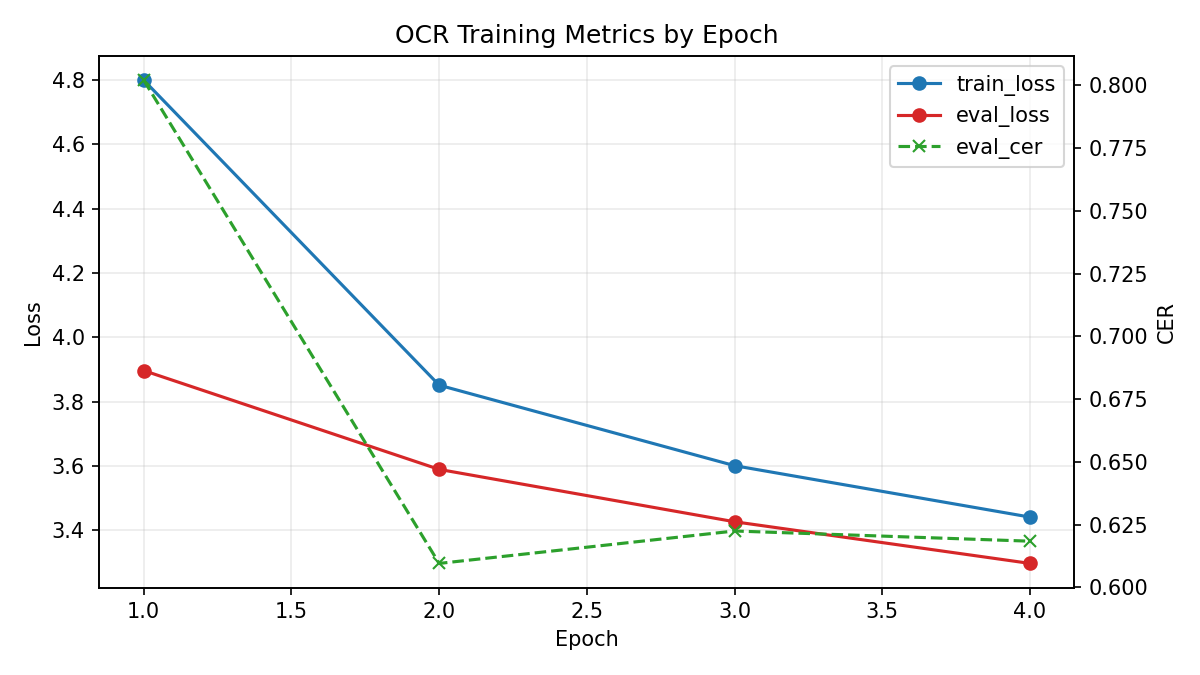

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/362 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'config': {'data_root': 'C:\\Users\\Francis BACKELAND\\.cache\\kagglehub\\datasets\\osamahosamabdellatif\\high-quality-invoice-images-for-ocr\\versions\\3',
  'output_dir': 'D:\\Projet\\scanned_images_classifier\\notebooks\\artifacts\\doc_understanding_ocr_cpu',
  'model_name': 'microsoft/trocr-small-printed',
  'train_csvs': ('outputs/batch1_train_split.csv',),
  'eval_csv': 'outputs/batch1_test_split.csv',
  'image_subdirs_train': ('.',),
  'image_subdir_eval': '.',
  'max_train_samples': 0,
  'max_eval_samples': 0,
  'max_target_length': 256,
  'image_size': 768,
  'use_grayscale': True,
  'learning_rate': 3e-05,
  'train_epochs': 10,
  'per_device_train_batch_size': 2,
  'per_device_eval_batch_size': 2,
  'random_seed': 3407,
  'lr_scheduler_type': 'cosine',
  'early_stopping_patience': 2,
  'early_stopping_threshold': 0.0,
  'metric_for_best_model': 'eval_cer',
  'greater_is_better': False,
  'allow_long_training': False,
  'require_supervised_eval': True,
  'allow_unlabeled_eval

In [5]:
# Preset principal: batch_1 split (70/30) with supervised validation on batch1_test_split
MODEL_NAME = "microsoft/trocr-small-printed"
EPOCHS = 10  # hard cap is enforced in train.py; early stopping is enabled on eval_cer
ALLOW_LONG_TRAINING = False  # kept for compatibility
MAX_TRAIN_SAMPLES = 0  # <=0 => full batch_1 train split
MAX_EVAL_SAMPLES = 0   # <=0 => full batch_1 test split
TRAIN_BATCH_SIZE = 2
EVAL_BATCH_SIZE = 2
LEARNING_RATE = 3e-5
IMAGE_SIZE = 768
USE_GRAYSCALE = True
cfg = TrainConfig(
    data_root=data_root,
    output_dir=output_dir,
    model_name=MODEL_NAME,
    train_csvs=("outputs/batch1_train_split.csv",),
    eval_csv="outputs/batch1_test_split.csv",
    image_subdirs_train=(".",),
    image_subdir_eval=".",
    max_train_samples=MAX_TRAIN_SAMPLES,
    max_eval_samples=MAX_EVAL_SAMPLES,
    train_epochs=EPOCHS,
    allow_long_training=ALLOW_LONG_TRAINING,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    image_size=IMAGE_SIZE,
    use_grayscale=USE_GRAYSCALE,
    generation_num_beams=2,
    generation_length_penalty=1.0,
    generation_no_repeat_ngram_size=5,
    generation_repetition_penalty=1.2,
)
summary = run_training(cfg)
summary


plot_path: D:\Projet\scanned_images_classifier\notebooks\artifacts\doc_understanding_ocr_cpu\training_metrics.png
history_path: D:\Projet\scanned_images_classifier\notebooks\artifacts\doc_understanding_ocr_cpu\metrics_history.json


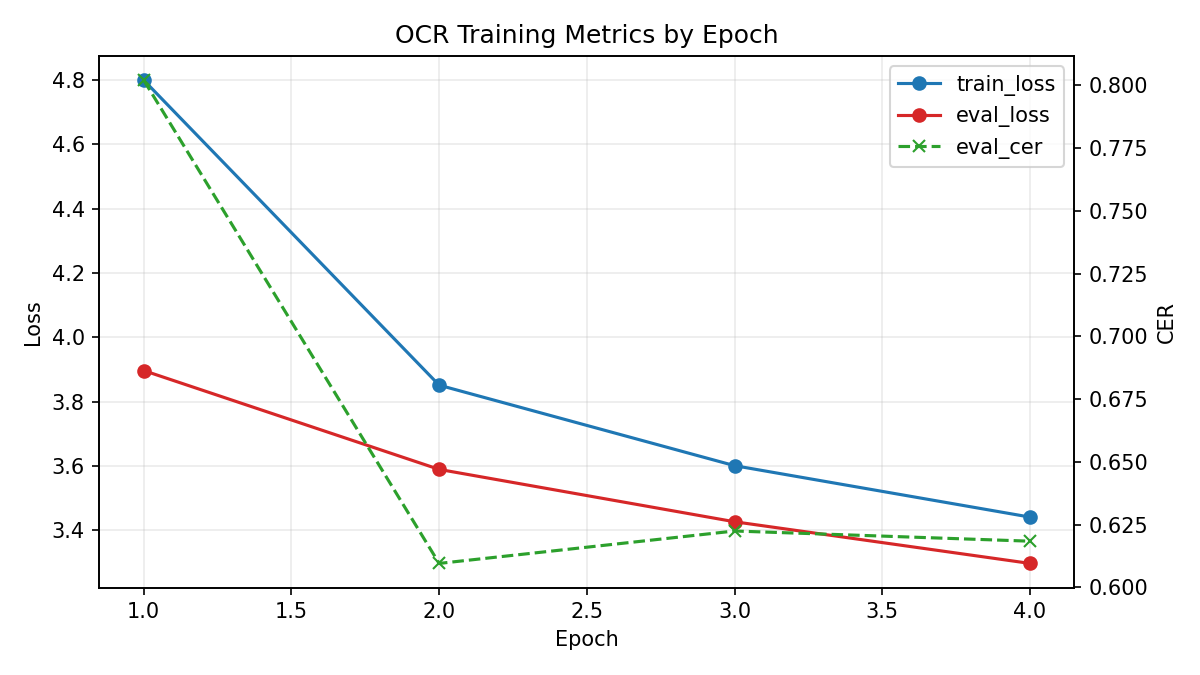

,epoch,loss
0,1.0,4.799340
1,2.0,3.850866
2,3.0,3.600617
3,4.0,3.440682


,epoch,loss,cer,step
0,1.0,3.896308,0.802087,495
1,2.0,3.589022,0.609524,990
2,3.0,3.426206,0.622445,1485
3,4.0,3.296661,0.618384,1980


C:\Users\Francis BACKELAND\AppData\Local\Temp\ipykernel_23068\543699508.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [6]:
from IPython.display import Image, display
import pandas as pd
import matplotlib.pyplot as plt

plot_path = output_dir / "training_metrics.png"
history_path = output_dir / "metrics_history.json"

print("plot_path:", plot_path)
print("history_path:", history_path)
if plot_path.exists():
    display(Image(filename=str(plot_path)))
else:
    print("Plot not found yet.")

if history_path.exists():
    history = json.loads(history_path.read_text(encoding="utf-8"))
    train_df = pd.DataFrame(history.get("train", []))
    eval_df = pd.DataFrame(history.get("eval", []))
    display(train_df.tail())
    display(eval_df.tail())
    if eval_df.empty:
        print("Warning: no eval_loss logged yet. Check eval strategy / completed epoch.")

    plt.figure(figsize=(8,4))
    if not train_df.empty:
        plt.plot(train_df["epoch"], train_df["loss"], marker="o", label="train_loss")
    if not eval_df.empty:
        plt.plot(eval_df["epoch"], eval_df["loss"], marker="o", label="eval_loss")
    plt.title("Train vs Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()
else:
    print("metrics_history.json not found yet.")


In [7]:
# Cellule suivi tests + val loss
import json
import subprocess, sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

cmd = [
    sys.executable, "-m", "unittest", "discover",
    "-s", "tests/apps",
    "-p", "test_doc_understanding_cpu_gradio_smoke.py",
]
res = subprocess.run(cmd, capture_output=True, text=True, cwd=str(PROJECT_ROOT))
print("--- unit tests stdout ---")
print(res.stdout)
print("--- unit tests stderr ---")
print(res.stderr)
print("returncode:", res.returncode)

metrics_obj = globals().get("metrics")
if metrics_obj is not None:
    print("current_val_metrics:", metrics_obj)
else:
    eval_path = PROJECT_ROOT / "notebooks" / "artifacts" / "doc_understanding_ocr_cpu" / "eval_metrics.json"
    if eval_path.exists():
        payload = json.loads(eval_path.read_text(encoding="utf-8"))
        print("current_val_metrics:", payload.get("metrics", payload))
    else:
        print("current_val_metrics: not available yet")


--- unit tests stdout ---

--- unit tests stderr ---
..
----------------------------------------------------------------------
Ran 2 tests in 0.001s

OK

returncode: 0
current_val_metrics: {'mode': 'unlabeled_batch2_validation', 'best_decode': {'num_beams': 4, 'no_repeat_ngram_size': 4, 'repetition_penalty': 1.15, 'max_new_tokens': 192}, 'best_metrics': {'num_samples': 100, 'non_empty_rate': 1.0, 'avg_prediction_chars': 196.43, 'avg_latency_ms': 384590.1175500002}, 'all_decode_runs': [{'decode': {'num_beams': 4, 'no_repeat_ngram_size': 4, 'repetition_penalty': 1.15, 'max_new_tokens': 192}, 'metrics': {'num_samples': 100, 'non_empty_rate': 1.0, 'avg_prediction_chars': 196.43, 'avg_latency_ms': 384590.1175500002}, 'sample_predictions': [{'image_path': 'C:\\Users\\Francis BACKELAND\\.cache\\kagglehub\\datasets\\osamahosamabdellatif\\high-quality-invoice-images-for-ocr\\versions\\3\\batch_2\\batch_2\\batch2_1\\batch2-0001.jpg', 'prediction': 'Invoice no: 07/17/2013 Seller: Client: Wilson-O

In [8]:
# Supervised decode + preprocessing ablation on batch_1 test split (CER/WER first)
eval_records_supervised = load_multi_ocr_sources(
    data_root=data_root,
    csv_paths=("outputs/batch1_test_split.csv",),
    image_subdirs=(".",),
)
if MAX_EVAL_SAMPLES > 0:
    eval_records_supervised = eval_records_supervised[:MAX_EVAL_SAMPLES]

print("num_eval_records_supervised:", len(eval_records_supervised))

decode_grid = [
    {"use_grayscale": True,  "num_beams": 1, "no_repeat_ngram_size": 5, "repetition_penalty": 1.2, "max_new_tokens": 80},
    {"use_grayscale": True,  "num_beams": 2, "no_repeat_ngram_size": 5, "repetition_penalty": 1.2, "max_new_tokens": 96},
    {"use_grayscale": False, "num_beams": 1, "no_repeat_ngram_size": 5, "repetition_penalty": 1.2, "max_new_tokens": 80},
]

eval_runs = []
for grid in decode_grid:
    predictor_i = load_predictor(
        InferConfig(
            artifacts_dir=output_dir,
            max_new_tokens=grid["max_new_tokens"],
            image_size=IMAGE_SIZE,
            use_grayscale=grid["use_grayscale"],
            num_beams=grid["num_beams"],
            length_penalty=1.0,
            no_repeat_ngram_size=grid["no_repeat_ngram_size"],
            repetition_penalty=grid["repetition_penalty"],
            temperature=0.0,
            segmentation_mode="line_only",
            max_chars_per_segment=256,
            max_total_chars=1200,
            max_invoice_markers_per_page=4,
            hard_truncate_segment_text=True,
        )
    )

    preds = {}
    rows = []
    total_latency = 0.0
    fallback_count = 0
    for rec in eval_records_supervised:
        out = predictor_i.predict(rec.image_path)
        pred = str(out.get("prediction", ""))
        lat = float(out.get("latency_ms", 0.0))
        used_fallback = bool(out.get("used_full_page_fallback", False))
        preds[rec.img_name] = pred
        total_latency += lat
        fallback_count += int(used_fallback)
        rows.append(
            {
                "img_name": rec.img_name,
                "image_path": str(rec.image_path),
                "prediction": pred,
                "latency_ms": lat,
                "used_full_page_fallback": used_fallback,
                "fallback_reason": out.get("fallback_reason"),
            }
        )

    n = max(len(eval_records_supervised), 1)
    metrics = evaluate_records(eval_records_supervised, preds, compute_wer=True)
    metrics["avg_latency_ms"] = total_latency / n
    metrics["full_page_fallback_rate"] = fallback_count / n
    eval_runs.append({"decode": grid, "metrics": metrics, "sample_predictions": rows[:5]})

# Priority: CER, then WER, then fallback rate, then latency
best_run = sorted(
    eval_runs,
    key=lambda x: (
        x["metrics"].get("cer", 1.0),
        x["metrics"].get("wer", 1.0),
        x["metrics"].get("full_page_fallback_rate", 1.0),
        x["metrics"].get("avg_latency_ms", 1e18),
    ),
)[0]
best_decode = best_run["decode"]

predictor = load_predictor(
    InferConfig(
        artifacts_dir=output_dir,
        max_new_tokens=best_decode["max_new_tokens"],
        image_size=IMAGE_SIZE,
        use_grayscale=best_decode["use_grayscale"],
        num_beams=best_decode["num_beams"],
        length_penalty=1.0,
        no_repeat_ngram_size=best_decode["no_repeat_ngram_size"],
        repetition_penalty=best_decode["repetition_penalty"],
        temperature=0.0,
        segmentation_mode="line_only",
        max_chars_per_segment=256,
        max_total_chars=1200,
        max_invoice_markers_per_page=4,
        hard_truncate_segment_text=True,
    )
)
best_run


num_eval_records_supervised: 424


Loading weights:   0%|          | 0/362 [00:00<?, ?it/s]

Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

Loading weights:   0%|          | 0/362 [00:00<?, ?it/s]

Both `max_new_tokens` (=96) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=96) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=96) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=96) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

Loading weights:   0%|          | 0/362 [00:00<?, ?it/s]

Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

Loading weights:   0%|          | 0/362 [00:00<?, ?it/s]

{'decode': {'use_grayscale': False,
  'num_beams': 1,
  'no_repeat_ngram_size': 5,
  'repetition_penalty': 1.2,
  'max_new_tokens': 80},
 'metrics': {'mode': 'supervised',
  'num_samples': 424,
  'cer': 0.879852077289907,
  'field_exact_match_overall': 0.0,
  'field_exact_match_by_name': {'invoice_no': 0.0,
   'date_of_issue': 0.0,
   'tax_id': 0.0,
   'iban': 0.0},
  'field_coverage_by_name': {'invoice_no': 1.0,
   'date_of_issue': 0.4080188679245283,
   'tax_id': 1.0,
   'iban': 1.0},
  'non_empty_rate': 1.0,
  'avg_prediction_chars': 921.8514150943396,
  'avg_reference_chars': 810.5966981132076,
  'prediction_reference_length_ratio': 1.137250394974585,
  'repetition_rate': 0.9238938326729378,
  'total_prediction_chars': 390865,
  'total_reference_chars': 343693,
  'wer': 0.992936720522751,
  'avg_latency_ms': 52733.809363207525,
  'full_page_fallback_rate': 0.0},
 'sample_predictions': [{'img_name': 'batch1-1395.jpg',
   'image_path': 'C:\\Users\\Francis BACKELAND\\.cache\\kagglehub

In [9]:
LATENCY_TARGET_MS = 20_000.0

metrics_payload = {
    "mode": "supervised_batch1_test_split_validation",
    "best_decode": best_decode,
    "best_metrics": best_run["metrics"],
    "all_decode_runs": [{"decode": r["decode"], "metrics": r["metrics"]} for r in eval_runs],
    "num_eval_records": len(eval_records_supervised),
    "latency_target_ms": LATENCY_TARGET_MS,
    "latency_target_met": bool(best_run["metrics"].get("avg_latency_ms", 1e18) <= LATENCY_TARGET_MS),
    "checkpoint_selection": summary.get("checkpoint_selection"),
    "supervised_eval_enabled": summary.get("supervised_eval_enabled"),
    "effective_image_size": predictor.effective_image_size,
}
metrics_path = output_dir / "eval_metrics.json"
metrics_path.write_text(json.dumps(metrics_payload, indent=2, ensure_ascii=False), encoding="utf-8")
print("saved:", metrics_path)
metrics_payload


saved: D:\Projet\scanned_images_classifier\notebooks\artifacts\doc_understanding_ocr_cpu\eval_metrics.json


{'mode': 'supervised_batch1_test_split_validation',
 'best_decode': {'use_grayscale': False,
  'num_beams': 1,
  'no_repeat_ngram_size': 5,
  'repetition_penalty': 1.2,
  'max_new_tokens': 80},
 'best_metrics': {'mode': 'supervised',
  'num_samples': 424,
  'cer': 0.879852077289907,
  'field_exact_match_overall': 0.0,
  'field_exact_match_by_name': {'invoice_no': 0.0,
   'date_of_issue': 0.0,
   'tax_id': 0.0,
   'iban': 0.0},
  'field_coverage_by_name': {'invoice_no': 1.0,
   'date_of_issue': 0.4080188679245283,
   'tax_id': 1.0,
   'iban': 1.0},
  'non_empty_rate': 1.0,
  'avg_prediction_chars': 921.8514150943396,
  'avg_reference_chars': 810.5966981132076,
  'prediction_reference_length_ratio': 1.137250394974585,
  'repetition_rate': 0.9238938326729378,
  'total_prediction_chars': 390865,
  'total_reference_chars': 343693,
  'wer': 0.992936720522751,
  'avg_latency_ms': 52733.809363207525,
  'full_page_fallback_rate': 0.0},
 'all_decode_runs': [{'decode': {'use_grayscale': True,
   

In [10]:
img_eval = data_root / "batch_1/batch_1/batch1_1/batch1-0001.jpg"
predictor.predict(img_eval)

Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

{'prediction': 'Invoice no: 91889 Date of issue: 08/27/2019 Seller: Client: Sons-Smith, Johnson and Sons 59821 Port Davidmouths Suite 879 Tax Id: 909-83-03 Tax Id: 942-87-7428 IBAN: GBZKJHQV4Y830080 ITEMS No. Description Qty UM Net\nInvoice no: 91889 Date of issue: 08/2019 Seller: Client: Smith-Johnson, Johnson and Sons 57998 Lake Suite 738 West Davidmouth, CT 030 Tax Id: 909-80-99 Tax Id: 942-87-628 IBAN: GBZKQVJ83008068 ITEMS No. Description Qty UM Net\nInvoice no: 91889 Date of issue: 01/2019 Seller: Client: Sons-Smith, Johnson and Sons 57921 Tax Id: 909-98-97 Tax Id: 942-87-91 IBAN: GBZKJHQV4868099 ITEMS No. Description Qty UM Net price Net worth VAT [%] Gross worth\nInvoice no: 91889 Date of issue: 08/2019 Seller: Client: Smith-Smith, Johnson and Sons 898 Port Apt. 579 South Joshuamouth, KS 499 Tax Id: 942-87-9772 IBAN: GBZJQV4Y3868068 ITEMS No. Description Qty UM Net price Net worth VAT [%',
 'extracted_text': 'Invoice no: 91889 Date of issue: 08/27/2019 Seller: Client: Sons-Smit

In [11]:
# Test inference sur une image batch_2
batch2_image = data_root / "batch_2/batch_2/batch2_1/batch2-0001.jpg"
result_batch2 = predictor.predict(batch2_image)
result_batch2

Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

{'prediction': 'Invoice no: 91889 Date of issue: 02/2019 Seller: Client: Johnson-Johnson, Robinson and Sons 898 Michaelmouths Suite 090 South Joshuaborough, MN 67997 Tax Id: 947-84-8568 IBAN: GB8ZJQV33008099 ITEMS No. Description Qty UM Net price Net worth VAT [%]\nInvoice no: 91889 Date of issue: 07/27/2019 Seller: Client: Sons-Smith, DPO AE 030 Tax Id: 909-97-98 Tax Id: 942-91-7471 IBAN: GBZKQV4S88768 ITEMS No. Description Qty UM Net price Net worth VAT [%] Gross\nInvoice no: 91889 Date of issue: 01/27/2016 Seller: Client: Sons-Smith, DPO AE 030 Tax Id: 909-98-97 Tax Id: 942-87-91 Tax IBAN: GBZKQV4YJH38680 ITEMS No. Description Qty UM Net price Net worth VAT [%\nInvoice no: 71889 Date of issue: 01/27/2016 Seller: Client: Sons-Smith, DPO AE 030 Tax Id: 938-98-97 Tax Id: 908-80-91 IBAN: GBZKQVJH4876899 ITEMS No. Description Qty UM Net price Net worth VAT [%] Gross',
 'extracted_text': 'Invoice no: 91889 Date of issue: 02/2019 Seller: Client: Johnson-Johnson, Robinson and Sons 898 Micha

## Test A/B

In [12]:
img_eval = data_root / "tests_AB/batch3-0501.jpg"
predictor.predict(img_eval)

Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

{'prediction': 'Invoice no: 91889 Date of issue: 08/2019 Seller: Client: Sons-Smith, Johnson and Sons 59821 Tax Id: 909-97-99 Tax Id: 952-91-8068 ITEMS No. Description Qty UM Net worth VAT [%] Gross worth 1. Nintendo 1,00 each 19,95 10% 21,50 10% 16,80 10% 12,90\nInvoice no: 91889 Date of issue: 08/21/2016 Seller: Client: Smith-Smith, Johnson and Sons 898 Michaelmouth Apt. 679 South Joshuaborough, KS 499 Tax Id: 943-84-8568 Tax IBAN: GBZJQV33008040 ITEMS No. Description Qty UM Net price Net worth VAT [%\nInvoice no: 91889 Date of issue: 07/29/2019 Seller: Client: Smith-Smith, Robinson and Sons 898 Port Apt. 679 South Garciamouth, NY 599 Tax Id: 968-8400 Tax IBAN: GBZQVJH4878040 ITEMS No. Description Qty UM Net price Net worth VAT [%\nInvoice no: 91820 Date of issue: 02/29/2019 Seller: Client: Smith-Smith, Johnson and Sons 898 Port Apt. 679 South Joshuamouth, KS 499 Tax Id: 984-866889 Tax IBAN: GBZJQV33008090 ITEMS No. Description Qty UM Net price Net worth VAT [%',
 'extracted_text': '

In [13]:
img_eval = data_root / "tests_AB/facture_hors_corpus.jpg"
predictor.predict(img_eval)

Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

{'prediction': 'Invoice no: 91889 Date of issue: 08/29/2017 Seller: Client: Smith-Smith, Johnson and Sons 59879 Michaelmouth, WI 030 Tax Id: 944-91-7468 IBAN: GBZJHQV3868099 ITEMS No. Description Qty UM Net price Net worth VAT [%] Gross worth 1. Nintendo 1,00\nInvoice no: 71889 Date of issue: 11/27/2019 Seller: Client: Sons-Smith, DPO AE 030 Tax Id: 938-98-97 Tax Id: 908-80-91 IBAN: GBZQVJH4876899 ITEMS No. Description Qty UM Net price Net worth VAT [%] Gross\nInvoice no: 91889 Date of issue: 08/2019 Seller: Client: Smith-Johnson, Robinson and Sons 898 Michaelmouth Apt: 679 South Joshuaborough, NY 59997 Tax Id: 947-84-8568 IBAN: GBZJQV3868040 ITEMS No. Description Qty UM Net price Net worth VAT [%]\nInvoice no: 918/25 Date of issue: 07/01/2013 Seller: Client: Sons-Smith, DPO AE 030 Tax Id: 909-98-9779 Tax IBAN: GBZQUJH48789 ITEMS No. Description Qty UM Net worth VAT [%] Gross worth 1. Nintendo 1,00 each 19,99 10% 21,',
 'extracted_text': 'Invoice no: 91889 Date of issue: 08/29/2017 Sel

In [14]:
img_eval = data_root / "tests_AB/avril2025auchan-local1704202519042029S0C0epagny-1.jpg"
predictor.predict(img_eval)

Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{'prediction': 'Invoice no: 918/25 Date of issue: 11/1921 Seller: Client: Sons-Smith, Johnson and Sons 57997 Michaelmouth, VT 819 Tax Id: 909-8068 IBAN: GBZJQV4899949 ITEMS No. Description Qty UM Net worth VAT [%] Gross worth 1. Nintendo 1,00 each 19,98 10%\nInvoice no: 918/25 Date of issue: 07/1921 Seller: Client: Sons-SPOJH 48698 Tax Id: 982-91 Tax IBAN: GB6ZQU4OX38979 ITEMS No. Description Qty UM Net worth VAT [%] Gross worth 1. Nintendo 1,00 each 19,99 10% 1 3 5 2 200\nInvoice no: 91889 Date of issue: 09/07/2017 Seller: Client: Smith-Smith, Johnson and Sons Apt. 898 Williamsmouth, Box 090 South Knolls Suite 679 West Joshuaborough, KS 49997 Tax Id: 944-86-9068 ITEMS No. 951-00 IBAN: GBZJQX4Y3300',
 'extracted_text': 'Invoice no: 918/25 Date of issue: 11/1921 Seller: Client: Sons-Smith, Johnson and Sons 57997 Michaelmouth, VT 819 Tax Id: 909-8068 IBAN: GBZJQV4899949 ITEMS No. Description Qty UM Net worth VAT [%] Gross worth 1. Nintendo 1,00 each 19,98 10%\nInvoice no: 918/25 Date of 

## Lancer Gradio avec ce modele

```bash
python src/apps/doc_understanding_cpu_gradio.py --model-dir notebooks/artifacts/doc_understanding_ocr_cpu/model --model-meta-path notebooks/artifacts/doc_understanding_ocr_cpu/model_meta.json --host 127.0.0.1 --port 7862
```

Conseil test decode: comparer `num_beams=4` et `num_beams=6`, puis `no_repeat_ngram_size=3/4` et `repetition_penalty=1.1`.
